# E-Commerce Layer — Exploratory Data Analysis

## What this layer represents

Otacon Inc. is a B2B technology company selling hardware, software, accessories, services, and consumables to 8,000 enterprise customers. This layer captures the core commercial engine: who buys, what they buy, when they buy, and what they return.

**Tables:** `customers` (8,000+), `products` (500), `orders` (~70K), `order_items` (~235K), `returns` (~4K)

**Time range:** January 2023 – December 2025 (3 full years)

**Business context to keep in mind:**
- B2B, not B2C — orders are large (avg ~$200K), seasonal patterns follow fiscal year cycles, not consumer holidays
- Wholesale customers (60%) place larger, multi-item orders; DTC customers (40%) order fewer items
- Enterprise customers get bigger discounts (10-25%) than SMBs (0-8%)

**Key questions this notebook answers:**
1. Is the business growing? How fast? Is growth accelerating or decelerating?
2. What products drive revenue vs. volume?
3. Are there seasonal patterns? Are they consistent year over year?
4. What happened to revenue in Q2 2025? Why?
5. How healthy is the return rate? Are any categories problematic?
6. How does data quality affect our analysis?

## 1. Setup & Data Quality Profiling

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import os
warnings.filterwarnings("ignore")

if os.path.exists("otacon.db"):
    DB_PATH = "otacon.db"
elif os.path.exists("../otacon.db"):
    DB_PATH = "../otacon.db"
else:
    raise FileNotFoundError("otacon.db not found. Run from project root or notebooks/ folder.")

conn = sqlite3.connect(DB_PATH)

def q(sql):
    return pd.read_sql_query(sql, conn)

def raw_vs_clean(raw_table, clean_view):
    raw = q(f"SELECT COUNT(*) as n FROM {raw_table}").n[0]
    clean = q(f"SELECT COUNT(*) as n FROM {clean_view}").n[0]
    excluded = raw - clean
    pct = round(excluded / raw * 100, 2) if raw > 0 else 0
    print(f"  {raw_table}: {raw:,} raw > {clean:,} clean ({excluded:,} excluded, {pct}%)")
    return raw, clean, excluded

def show_flags(table_name):
    sql = ("SELECT rule_id, flag_type, COUNT(*) as cnt, "
           "MIN(description) as example "
           "FROM data_quality_flags "
           "WHERE table_name = '" + table_name + "' "
           "GROUP BY rule_id, flag_type ORDER BY rule_id")
    df = q(sql)
    if df.empty:
        print(f"  No flags for {table_name}")
    else:
        for _, r in df.iterrows():
            print(f"  {r.rule_id} ({r.flag_type}): {r.cnt:,} - {r.example[:80]}")
    return df

import plotly.io as pio
pio.templates.default = "plotly_white"

table_count = q("SELECT COUNT(*) as n FROM sqlite_master WHERE type='table'").n[0]
view_count = q("SELECT COUNT(*) as n FROM sqlite_master WHERE type='view'").n[0]
print("Connected to", DB_PATH)
print("Tables:", table_count)
print("Views:", view_count)


Connected to ../otacon.db
Tables: 22
Views: 12


In [2]:
# ── Data quality overview ──
print("=" * 65)
print("  DATA QUALITY: RAW vs CLEAN")
print("=" * 65)
for raw, clean in [("customers", "v_customers_clean"),
                    ("orders", "v_orders_clean"),
                    ("order_items", "v_order_items_clean"),
                    ("returns", "v_returns_clean")]:
    raw_vs_clean(raw, clean)

print("\n" + "=" * 65)
print("  DATA QUALITY FLAGS")
print("=" * 65)
for t in ["customers", "orders", "order_items"]:
    print(f"\n  [{t.upper()}]")
    show_flags(t)


  DATA QUALITY: RAW vs CLEAN
  customers: 8,240 raw > 8,000 clean (240 excluded, 2.91%)
  orders: 69,663 raw > 68,970 clean (693 excluded, 0.99%)
  order_items: 235,183 raw > 188,617 clean (46,566 excluded, 19.8%)
  returns: 4,009 raw > 3,972 clean (37 excluded, 0.92%)

  DATA QUALITY FLAGS

  [CUSTOMERS]
  FLG-002 (duplicate_suspect): 1,135 - Matches duplicate cluster: ADAMS PLC / North America
  FLG-007 (whitespace_issue): 711 - Company name has leading/trailing/double whitespace

  [ORDERS]
  FLG-005 (orphaned_fk): 348 - customer_id=90001 does not match any customer
  FLG-008 (future_date): 348 - order_date=2032-01-07 is beyond data range

  [ORDER_ITEMS]
  FLG-001 (outlier): 244 - unit_price exceeds 3 std devs (threshold: 688445.20)


### What governance is doing

The clean views exclude:
- **240 duplicate customers** (near-duplicates injected by the messiness layer, tracked in `_messiness_duplicates`)
- **~693 orders** with orphaned customer_ids (pointing to customer_id ≥ 90001, which don't exist) or future-dated order_dates (typos like 2032, 2042)
- **~46K order line items** excluded because they're tied to excluded orders OR have extreme unit_price outliers

This means ~1% of orders and ~3% of customers are dirty. That's realistic for enterprise data — and the clean views handle it transparently.

In [3]:
# ── Null analysis across raw tables ──
print("NULL RATES IN RAW TABLES:")
for table in ["customers", "orders", "order_items", "returns"]:
    df = q(f"SELECT * FROM {table} LIMIT 5000")
    nulls = (df.isnull().sum() / len(df) * 100).round(2)
    has_nulls = nulls[nulls > 0]
    if has_nulls.empty:
        print(f"  {table}: no nulls")
    else:
        for col, pct in has_nulls.items():
            print(f"  {table}.{col}: {pct}% null")

# Region variants in raw data
print("\nREGION VARIANTS (raw customers):")
regions = q("SELECT region, COUNT(*) as n FROM customers GROUP BY region ORDER BY n DESC")
for _, r in regions.iterrows():
    canonical = "✓" if r.region in ["North America", "Europe", "APAC", "LATAM"] else "✗ variant"
    print(f"  '{r.region}': {r.n:,} {canonical}")

print(f"\nAfter governance standardization:")
clean_regions = q("SELECT region, COUNT(*) as n FROM v_customers_clean GROUP BY region ORDER BY n DESC")
for _, r in clean_regions.iterrows():
    print(f"  '{r.region}': {r.n:,}")


NULL RATES IN RAW TABLES:
  customers: no nulls
  orders: no nulls
  order_items: no nulls
  returns: no nulls

REGION VARIANTS (raw customers):
  'North America': 3,489 ✓
  'Europe': 1,957 ✓
  'APAC': 1,608 ✓
  'LATAM': 777 ✓
  'North_America': 44 ✗ variant
  'NorthAmerica': 42 ✗ variant
  'north america': 41 ✗ variant
  'NA': 34 ✗ variant
  'N. America': 31 ✗ variant
  'EMEA': 29 ✗ variant
  'EU': 27 ✗ variant
  'Asia Pacific': 27 ✗ variant
  'Europe ': 23 ✗ variant
  'AP': 23 ✗ variant
  'europe': 18 ✗ variant
  'apac': 16 ✗ variant
  'Asia-Pacific': 16 ✗ variant
  'latam': 10 ✗ variant
  'South America': 10 ✗ variant
  'Latin America': 9 ✗ variant
  'LATAM ': 9 ✗ variant

After governance standardization:
  'North America': 3,576
  'Europe': 2,000
  'APAC': 1,633
  'LATAM': 791


## 2. Customer Base — Who Are Otacon's Customers?

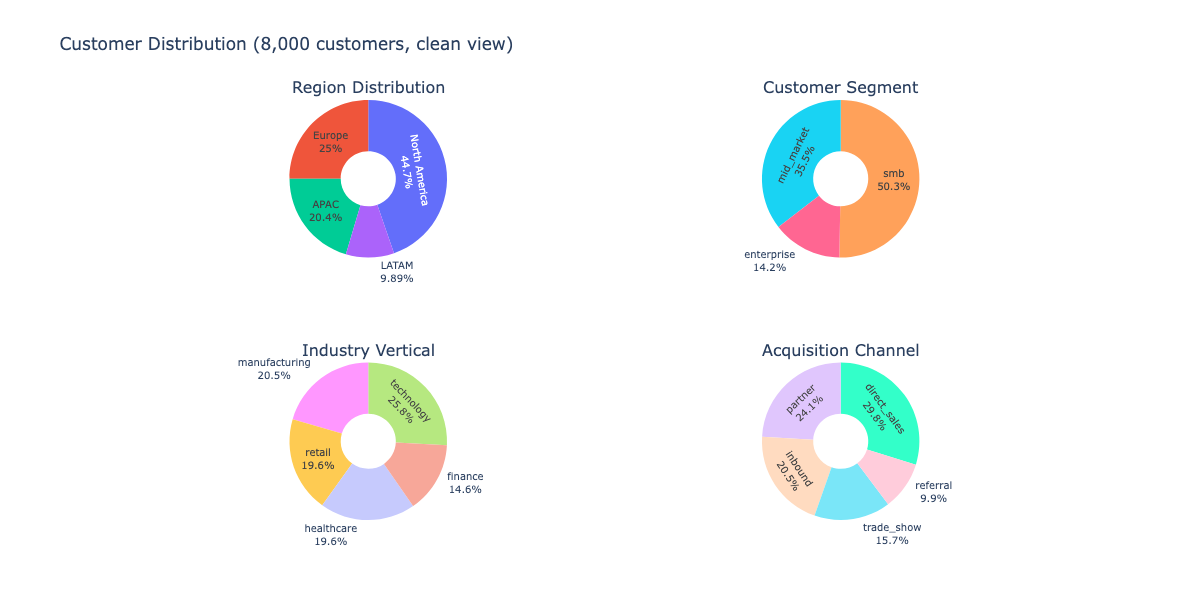


Segment breakdown:
  smb: 4,022 (50%)
  mid_market: 2,839 (35%)
  enterprise: 1,139 (14%)


In [4]:
# ── Customer distribution: 4-panel breakdown ──
cust = q("SELECT * FROM v_customers_clean")

fig = make_subplots(rows=2, cols=2,
    subplot_titles=("Region Distribution", "Customer Segment",
                    "Industry Vertical", "Acquisition Channel"),
    specs=[[{"type": "domain"}, {"type": "domain"}],
           [{"type": "domain"}, {"type": "domain"}]])

for i, col in enumerate(["region", "segment", "industry", "acquisition_channel"]):
    counts = cust[col].value_counts()
    row, c = divmod(i, 2)
    fig.add_trace(go.Pie(labels=counts.index, values=counts.values,
                         textinfo="label+percent", hole=0.35,
                         textfont_size=10),
                  row=row+1, col=c+1)

fig.update_layout(height=600, width=950,
                  title_text="Customer Distribution (8,000 customers, clean view)",
                  showlegend=False)
fig.show()

# Print the actual numbers
print("\nSegment breakdown:")
for seg, count in cust.segment.value_counts().items():
    print(f"  {seg}: {count:,} ({count/len(cust)*100:.0f}%)")


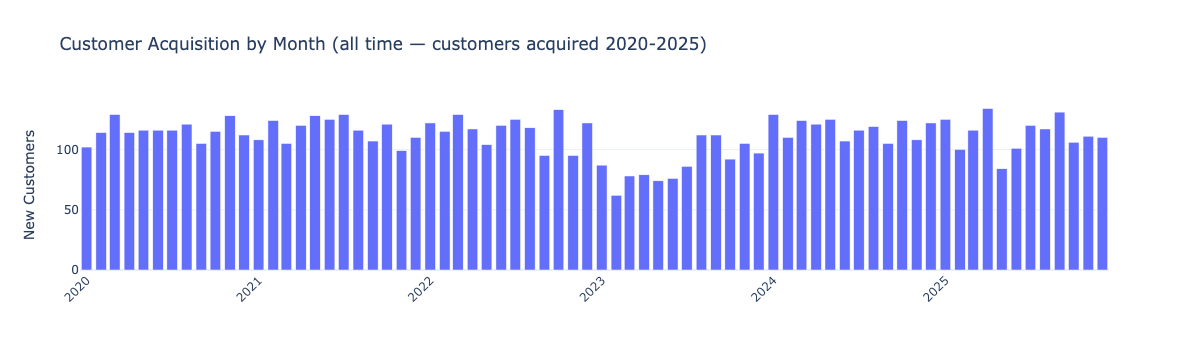


Customers acquired by year:
  2020: 1,388
  2021: 1,392
  2022: 1,395
  2023: 1,060
  2024: 1,410
  2025: 1,355


In [5]:
# ── Customer acquisition over time ──
cust["acq_month"] = pd.to_datetime(cust.acquisition_date).dt.to_period("M").astype(str)
acq = cust.groupby("acq_month").size().reset_index(name="new_customers")

fig = px.bar(acq, x="acq_month", y="new_customers",
             title="Customer Acquisition by Month (all time — customers acquired 2020-2025)",
             labels={"acq_month": "", "new_customers": "New Customers"})
fig.update_layout(height=350, width=950, xaxis_tickangle=-45)
fig.show()

# Acquisition by year
print("\nCustomers acquired by year:")
cust["acq_year"] = pd.to_datetime(cust.acquisition_date).dt.year
for yr, cnt in cust.acq_year.value_counts().sort_index().items():
    print(f"  {yr}: {cnt:,}")


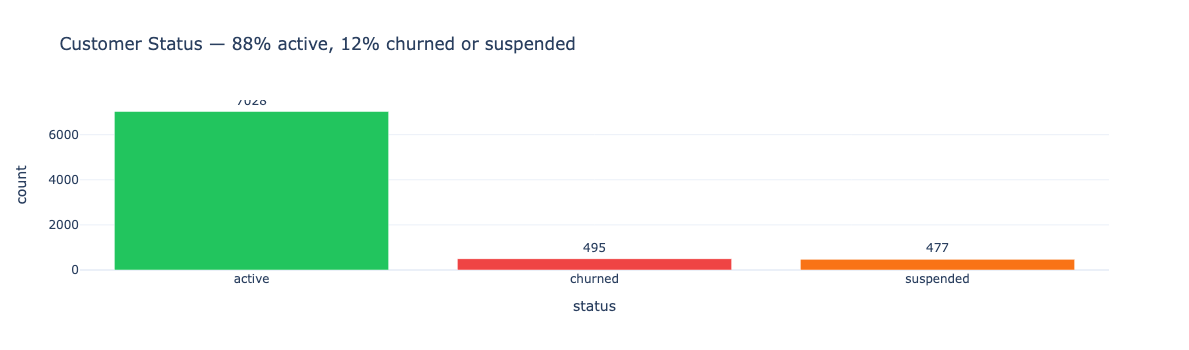

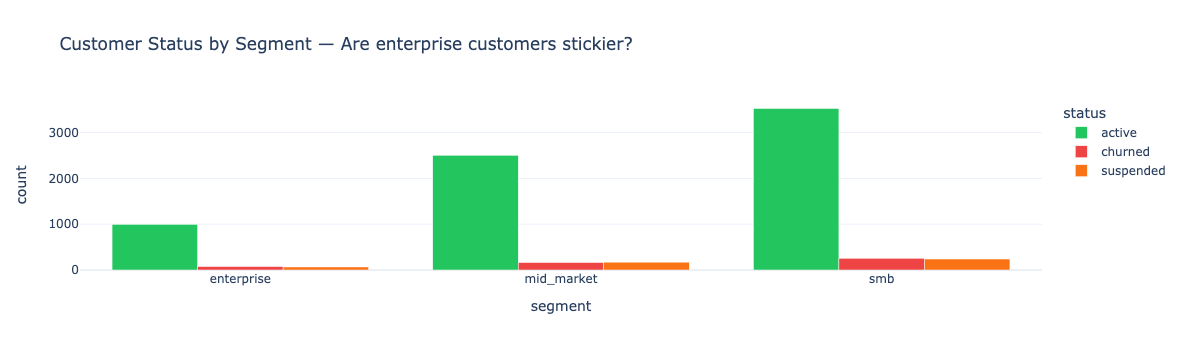

In [6]:
# ── Customer status: active vs churned vs suspended ──
status = cust.status.value_counts().reset_index()
status.columns = ["status", "count"]

fig = px.bar(status, x="status", y="count", color="status",
             title="Customer Status — 88% active, 12% churned or suspended",
             color_discrete_map={"active": "#22c55e", "churned": "#ef4444", "suspended": "#f97316"},
             text="count")
fig.update_traces(textposition="outside")
fig.update_layout(height=350, width=600, showlegend=False)
fig.show()

# Churn by segment
churn_seg = cust.groupby(["segment", "status"]).size().reset_index(name="count")
fig2 = px.bar(churn_seg, x="segment", y="count", color="status", barmode="group",
              title="Customer Status by Segment — Are enterprise customers stickier?",
              color_discrete_map={"active": "#22c55e", "churned": "#ef4444", "suspended": "#f97316"})
fig2.update_layout(height=350, width=700)
fig2.show()


## 3. Revenue Performance — Is the Business Growing?

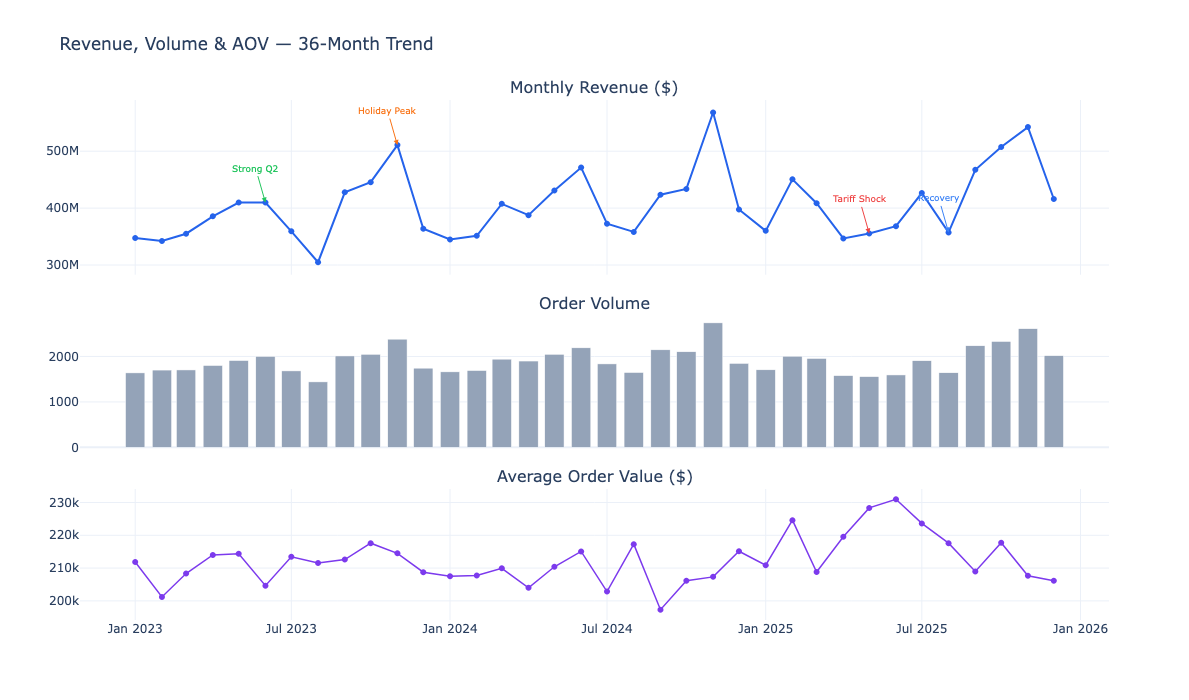

In [7]:
# ── Monthly revenue trend with YoY context ──
rev = q("""
    SELECT strftime('%Y-%m', order_date) as month,
           strftime('%Y', order_date) as year,
           SUM(total_amount) as revenue,
           COUNT(*) as orders,
           COUNT(DISTINCT customer_id) as unique_customers,
           AVG(total_amount) as avg_order_value,
           AVG(discount_pct) as avg_discount
    FROM v_orders_clean
    GROUP BY month ORDER BY month
""")

fig = make_subplots(rows=3, cols=1, shared_xaxes=True,
                    subplot_titles=("Monthly Revenue ($)", "Order Volume",
                                    "Average Order Value ($)"),
                    row_heights=[0.4, 0.3, 0.3],
                    vertical_spacing=0.08)

fig.add_trace(go.Scatter(x=rev.month, y=rev.revenue, mode="lines+markers",
                         line=dict(color="#2563eb", width=2), name="Revenue",
                         hovertemplate="%{x}: $%{y:,.0f}"),
              row=1, col=1)
fig.add_trace(go.Bar(x=rev.month, y=rev.orders, name="Orders",
                     marker_color="#94a3b8"), row=2, col=1)
fig.add_trace(go.Scatter(x=rev.month, y=rev.avg_order_value, mode="lines+markers",
                         line=dict(color="#7c3aed", width=1.5), name="Avg Order"),
              row=3, col=1)

# Annotate storylines
annotations = [
    ("2023-06", "Strong Q2", "#22c55e", 1),
    ("2023-11", "Holiday Peak", "#f97316", 1),
    ("2025-05", "Tariff Shock", "#ef4444", 1),
    ("2025-08", "Recovery", "#3b82f6", 1),
]
for month, label, color, row in annotations:
    if month in rev.month.values:
        y = rev[rev.month == month].revenue.values[0]
        fig.add_annotation(x=month, y=y, text=label, showarrow=True,
                          arrowhead=2, arrowcolor=color, ay=-35,
                          font=dict(size=9, color=color), row=row, col=1)

fig.update_layout(height=700, width=1000, showlegend=False,
                  title_text="Revenue, Volume & AOV — 36-Month Trend")
fig.show()


In [8]:
# ── Year-over-year comparison ──
yoy = q("""
    SELECT strftime('%Y', order_date) as year,
           SUM(total_amount) as revenue,
           COUNT(*) as orders,
           COUNT(DISTINCT customer_id) as customers,
           AVG(total_amount) as aov,
           AVG(discount_pct) * 100 as avg_discount_pct
    FROM v_orders_clean
    GROUP BY year ORDER BY year
""")
yoy["rev_growth"] = yoy.revenue.pct_change() * 100
yoy["order_growth"] = yoy.orders.pct_change() * 100

print("YEAR-OVER-YEAR PERFORMANCE")
print("=" * 75)
for _, r in yoy.iterrows():
    growth = f"  ({r.rev_growth:+.1f}% YoY)" if r.rev_growth == r.rev_growth else ""
    print(f"  {int(r.year)}: ${r.revenue/1e9:.2f}B revenue | {r.orders:,.0f} orders | "
          f"{r.customers:,.0f} customers | ${r.aov:,.0f} AOV | {r.avg_discount_pct:.1f}% disc{growth}")

print(f"\n  3-year total: ${yoy.revenue.sum()/1e9:.2f}B across {yoy.orders.sum():,.0f} orders")


YEAR-OVER-YEAR PERFORMANCE
  2023: $4.66B revenue | 22,067 orders | 7,501 customers | $211,245 AOV | 8.1% disc
  2024: $4.95B revenue | 23,757 orders | 7,580 customers | $208,239 AOV | 8.1% disc  (+6.1% YoY)
  2025: $5.01B revenue | 23,146 orders | 7,553 customers | $216,302 AOV | 8.1% disc  (+1.2% YoY)

  3-year total: $14.62B across 68,970 orders


### Key finding: Growth is decelerating

Revenue grew **6.1% from 2023→2024** but only **1.2% from 2024→2025**. That's a significant deceleration. The Q2 2025 tariff volatility is a likely culprit — let's investigate.

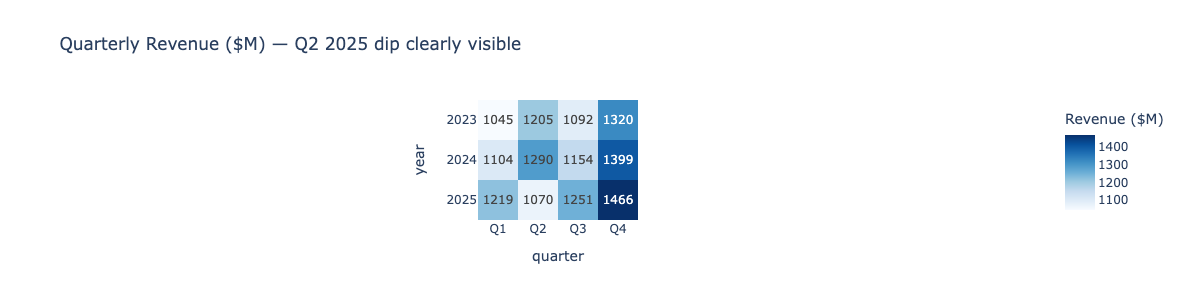

In [9]:
# ── Quarterly revenue heatmap ──
quarterly = q("""
    SELECT strftime('%Y', order_date) as year,
           'Q' || ((CAST(strftime('%m', order_date) AS INT) - 1) / 3 + 1) as quarter,
           SUM(total_amount) as revenue,
           COUNT(*) as orders
    FROM v_orders_clean
    GROUP BY year, quarter ORDER BY year, quarter
""")

pivot = quarterly.pivot(index="year", columns="quarter", values="revenue")
fig = px.imshow(pivot / 1e6, text_auto=".0f", color_continuous_scale="Blues",
                title="Quarterly Revenue ($M) — Q2 2025 dip clearly visible",
                labels={"color": "Revenue ($M)"})
fig.update_layout(height=300, width=600)
fig.show()


## 4. Seasonality — The B2B Calendar

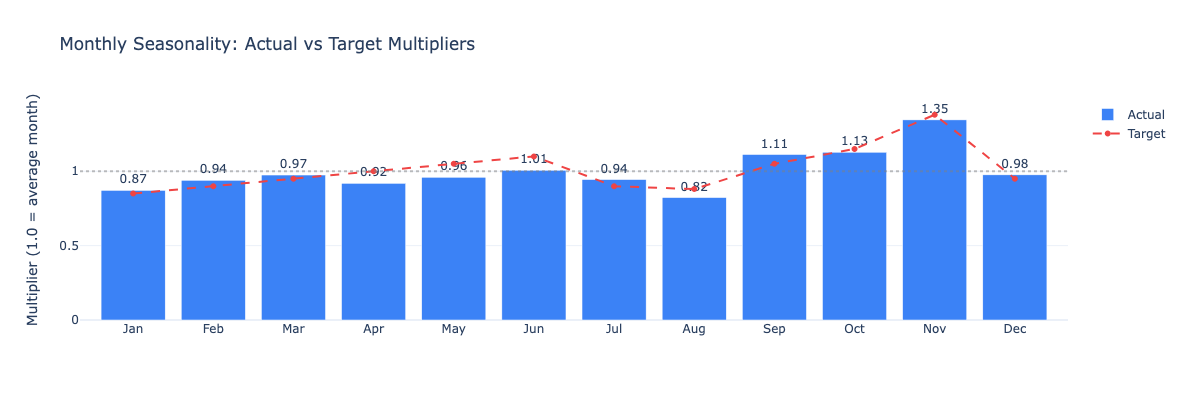


Key seasonal patterns:
  - November spike: B2B budget flush before fiscal year end
  - January dip: Post-holiday slowdown + returns processing
  - Summer trough (Jul-Aug): Decision-makers on vacation
  - Q4 ramp (Sep-Nov): Budget planning and year-end purchasing


In [10]:
# ── Monthly multipliers: actual vs configured ──
monthly_avg = q("""
    SELECT CAST(strftime('%m', order_date) AS INT) as month_num,
           AVG(total_amount) as avg_rev,
           COUNT(*) as total_orders
    FROM v_orders_clean
    GROUP BY month_num ORDER BY month_num
""")
overall_avg = monthly_avg.total_orders.mean()
monthly_avg["multiplier"] = monthly_avg.total_orders / overall_avg

target_multipliers = {1:0.85, 2:0.90, 3:0.95, 4:1.00, 5:1.05, 6:1.10,
                      7:0.90, 8:0.88, 9:1.05, 10:1.15, 11:1.38, 12:0.95}
monthly_avg["target"] = monthly_avg.month_num.map(target_multipliers)

month_names = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
               7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
monthly_avg["month_name"] = monthly_avg.month_num.map(month_names)

fig = go.Figure()
fig.add_trace(go.Bar(x=monthly_avg.month_name, y=monthly_avg.multiplier,
                     name="Actual", marker_color="#3b82f6", text=monthly_avg.multiplier.round(2),
                     textposition="outside"))
fig.add_trace(go.Scatter(x=monthly_avg.month_name, y=monthly_avg.target,
                         name="Target", mode="lines+markers",
                         line=dict(color="#ef4444", dash="dash", width=2)))
fig.update_layout(title="Monthly Seasonality: Actual vs Target Multipliers",
                  yaxis_title="Multiplier (1.0 = average month)",
                  height=400, width=800, barmode="group")
fig.add_hline(y=1.0, line_dash="dot", line_color="gray", opacity=0.5)
fig.show()

print("\nKey seasonal patterns:")
print("  - November spike: B2B budget flush before fiscal year end")
print("  - January dip: Post-holiday slowdown + returns processing")
print("  - Summer trough (Jul-Aug): Decision-makers on vacation")
print("  - Q4 ramp (Sep-Nov): Budget planning and year-end purchasing")


## 5. The Q2 2025 Tariff Shock — Deep Dive

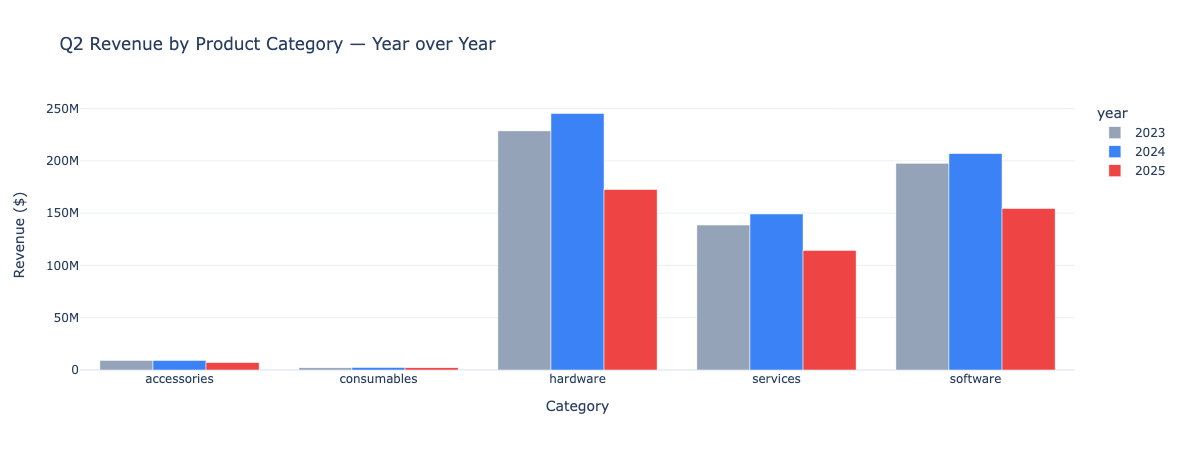


Q2 2025 vs Q2 2024 by category:
  accessories: -21.8%
  consumables: -11.2%
  hardware: -29.6%
  services: -23.4%
  software: -25.4%


In [11]:
# ── Revenue by category, Q2 each year ──
tariff = q("""
    SELECT strftime('%Y', o.order_date) as year, p.category,
           SUM(oi.line_total) as revenue,
           COUNT(DISTINCT oi.order_id) as orders,
           AVG(oi.unit_price) as avg_price
    FROM v_order_items_clean oi
    JOIN v_orders_clean o ON oi.order_id = o.order_id
    JOIN products p ON oi.product_id = p.product_id
    WHERE CAST(strftime('%m', o.order_date) AS INT) BETWEEN 4 AND 6
    GROUP BY year, category ORDER BY year, category
""")

fig = px.bar(tariff, x="category", y="revenue", color="year", barmode="group",
             title="Q2 Revenue by Product Category — Year over Year",
             labels={"revenue": "Revenue ($)", "category": "Category"},
             color_discrete_sequence=["#94a3b8", "#3b82f6", "#ef4444"])
fig.update_layout(height=450, width=800)
fig.show()

# Calculate the actual impact
print("\nQ2 2025 vs Q2 2024 by category:")
for cat in tariff.category.unique():
    q2_24 = tariff[(tariff.year=="2024") & (tariff.category==cat)].revenue.values
    q2_25 = tariff[(tariff.year=="2025") & (tariff.category==cat)].revenue.values
    if len(q2_24) > 0 and len(q2_25) > 0:
        pct = (q2_25[0] - q2_24[0]) / q2_24[0] * 100
        print(f"  {cat}: {pct:+.1f}%")


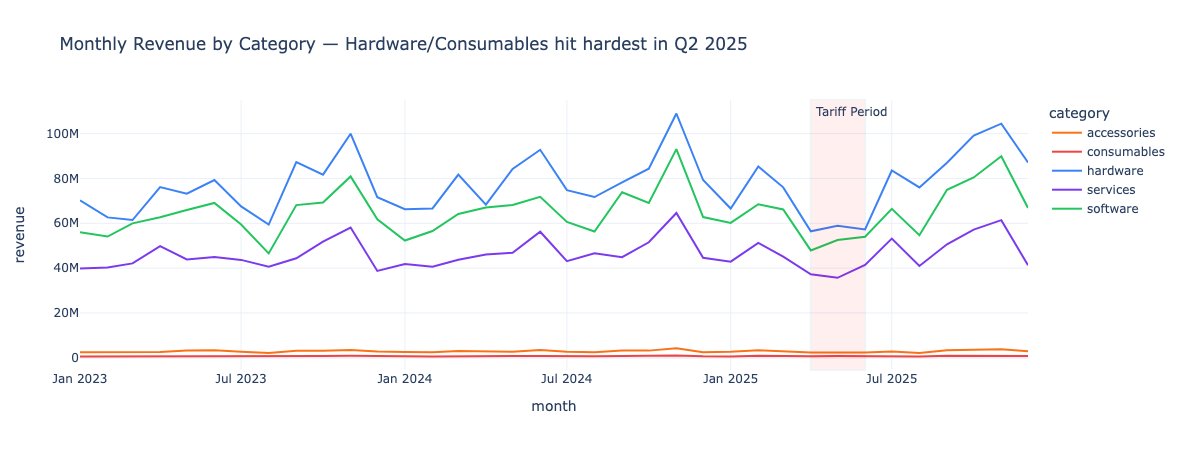

In [12]:
# ── Monthly revenue by category — full timeline to see tariff recovery ──
cat_monthly = q("""
    SELECT strftime('%Y-%m', o.order_date) as month, p.category,
           SUM(oi.line_total) as revenue
    FROM v_order_items_clean oi
    JOIN v_orders_clean o ON oi.order_id = o.order_id
    JOIN products p ON oi.product_id = p.product_id
    GROUP BY month, category ORDER BY month
""")

fig = px.line(cat_monthly, x="month", y="revenue", color="category",
              title="Monthly Revenue by Category — Hardware/Consumables hit hardest in Q2 2025",
              color_discrete_map={"hardware":"#3b82f6", "software":"#22c55e",
                                   "services":"#7c3aed", "accessories":"#f97316",
                                   "consumables":"#ef4444"})
fig.add_vrect(x0="2025-04", x1="2025-06", fillcolor="red", opacity=0.06,
              annotation_text="Tariff Period", annotation_position="top left")
fig.update_layout(height=450, width=1000)
fig.show()


## 6. Product Mix — What Drives Revenue vs. Volume?

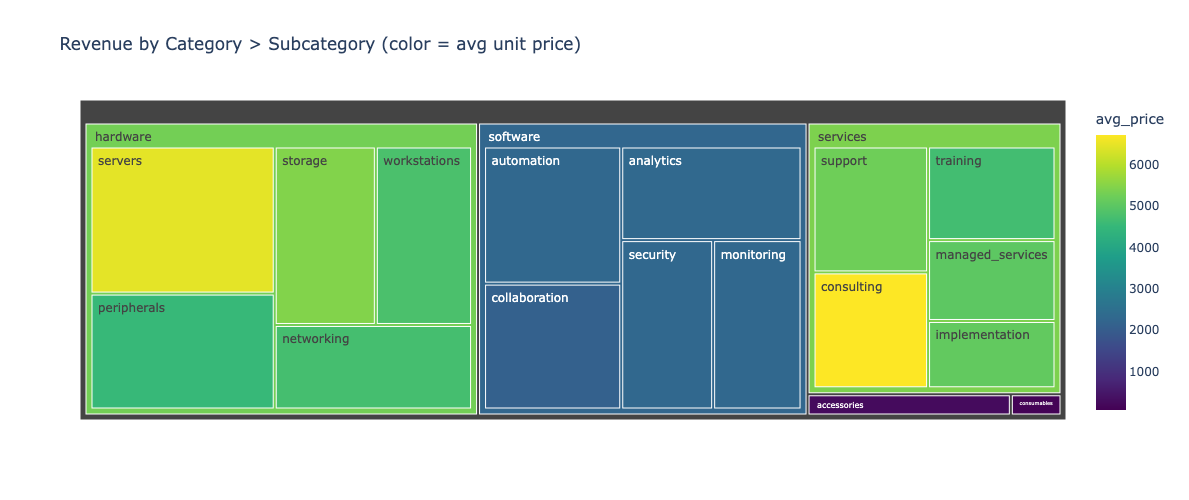


Category summary:
  hardware: $2,785M (40%) | 36,803.0 orders | $5,187 avg price
  software: $2,332M (34%) | 67,367.0 orders | $2,254 avg price
  services: $1,667M (24%) | 22,168.0 orders | $5,353 avg price
  accessories: $104M (2%) | 29,629.0 orders | $248 avg price
  consumables: $26M (0%) | 20,034.0 orders | $93 avg price


In [13]:
# ── Revenue vs volume treemap ──
products = q("""
    SELECT p.category, p.subcategory,
           SUM(oi.line_total) as revenue,
           SUM(oi.quantity) as units,
           COUNT(DISTINCT oi.order_id) as orders,
           AVG(oi.unit_price) as avg_price
    FROM v_order_items_clean oi
    JOIN products p ON oi.product_id = p.product_id
    GROUP BY p.category, p.subcategory ORDER BY revenue DESC
""")

fig = px.treemap(products, path=["category", "subcategory"], values="revenue",
                 color="avg_price", color_continuous_scale="Viridis",
                 title="Revenue by Category > Subcategory (color = avg unit price)")
fig.update_layout(height=500, width=950)
fig.show()

print("\nCategory summary:")
cat_summary = products.groupby("category").agg(
    revenue=("revenue", "sum"),
    orders=("orders", "sum"),
    avg_price=("avg_price", "mean")
).sort_values("revenue", ascending=False)
for cat, r in cat_summary.iterrows():
    pct = r.revenue / cat_summary.revenue.sum() * 100
    print(f"  {cat}: ${r.revenue/1e6:,.0f}M ({pct:.0f}%) | {r.orders:,} orders | ${r.avg_price:,.0f} avg price")


## 7. Discount Behavior

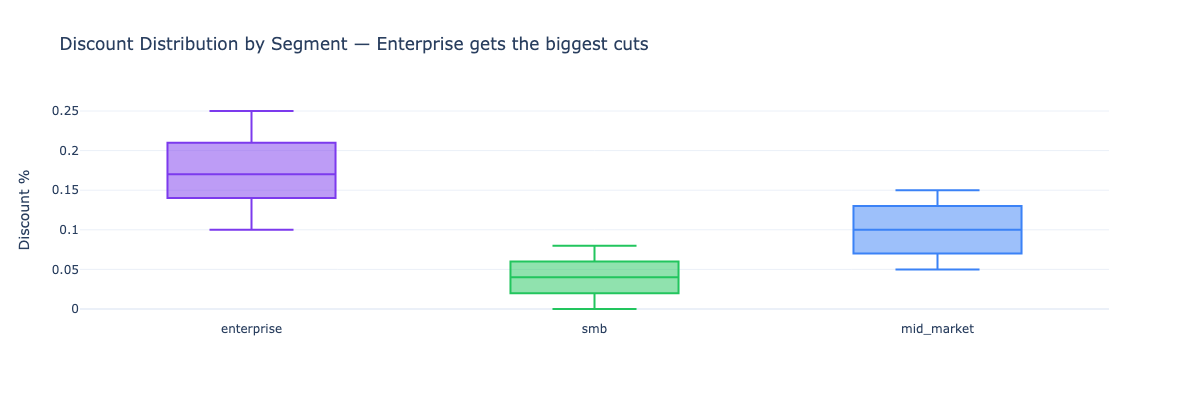


Average discount by segment:
  enterprise: 17.5%
  mid_market: 10.0%
  smb: 4.0%


In [14]:
# ── Discount distribution by segment ──
disc = q("""
    SELECT c.segment, o.discount_pct, o.total_amount
    FROM v_orders_clean o
    JOIN v_customers_clean c ON o.customer_id = c.customer_id
""")

fig = px.box(disc, x="segment", y="discount_pct", color="segment",
             title="Discount Distribution by Segment — Enterprise gets the biggest cuts",
             labels={"discount_pct": "Discount %", "segment": ""},
             color_discrete_map={"enterprise":"#7c3aed", "mid_market":"#3b82f6", "smb":"#22c55e"})
fig.update_layout(height=400, width=700, showlegend=False)
fig.show()

print("\nAverage discount by segment:")
for seg in ["enterprise", "mid_market", "smb"]:
    avg = disc[disc.segment == seg].discount_pct.mean() * 100
    print(f"  {seg}: {avg:.1f}%")


## 8. Returns — Are They Under Control?

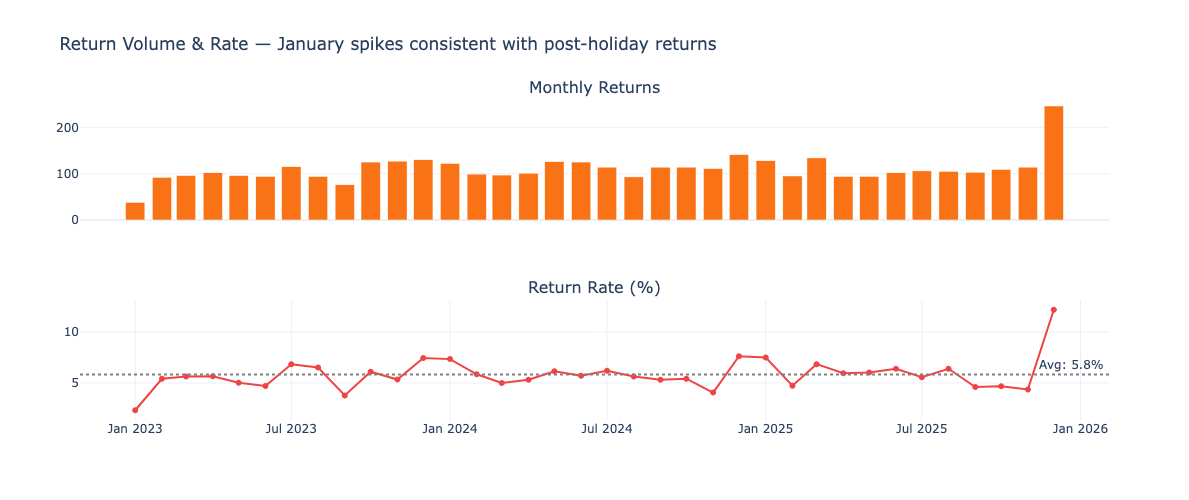

In [15]:
# ── Monthly return volume and rate ──
ret_monthly = q("""
    SELECT strftime('%Y-%m', r.return_date) as month,
           COUNT(*) as returns,
           SUM(r.refund_amount) as refund_total
    FROM v_returns_clean r
    GROUP BY month ORDER BY month
""")
orders_monthly = q("""
    SELECT strftime('%Y-%m', order_date) as month, COUNT(*) as orders
    FROM v_orders_clean GROUP BY month
""")
merged = ret_monthly.merge(orders_monthly, on="month", how="left")
merged["return_rate"] = merged.returns / merged.orders * 100

fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    subplot_titles=("Monthly Returns", "Return Rate (%)"),
                    row_heights=[0.5, 0.5])
fig.add_trace(go.Bar(x=merged.month, y=merged.returns, name="Returns",
                     marker_color="#f97316"), row=1, col=1)
fig.add_trace(go.Scatter(x=merged.month, y=merged.return_rate, name="Rate %",
                         mode="lines+markers", line=dict(color="#ef4444", width=2)),
              row=2, col=1)
fig.add_hline(y=merged.return_rate.mean(), line_dash="dot", line_color="gray",
              annotation_text=f"Avg: {merged.return_rate.mean():.1f}%", row=2, col=1)
fig.update_layout(height=500, width=1000, showlegend=False,
                  title_text="Return Volume & Rate — January spikes consistent with post-holiday returns")
fig.show()


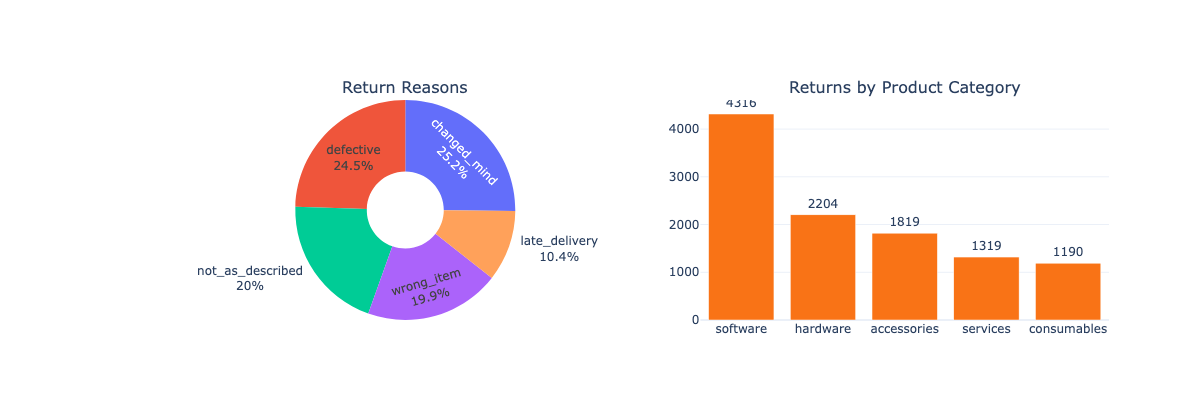


Return reasons:
  changed_mind: 999 (25%)
  defective: 975 (25%)
  not_as_described: 794 (20%)
  wrong_item: 789 (20%)
  late_delivery: 415 (10%)


In [16]:
# ── Return reasons breakdown + returns by category ──
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=("Return Reasons", "Returns by Product Category"),
                    specs=[[{"type": "domain"}, {"type": "xy"}]])

reasons = q("SELECT reason, COUNT(*) as cnt FROM v_returns_clean GROUP BY reason ORDER BY cnt DESC")
fig.add_trace(go.Pie(labels=reasons.reason, values=reasons.cnt, hole=0.35,
                     textinfo="label+percent"), row=1, col=1)

ret_cat = q("""
    SELECT p.category, COUNT(*) as returns,
           SUM(r.refund_amount) as refund_total
    FROM v_returns_clean r
    JOIN v_orders_clean o ON r.order_id = o.order_id
    JOIN v_order_items_clean oi ON o.order_id = oi.order_id
    JOIN products p ON oi.product_id = p.product_id
    GROUP BY p.category ORDER BY returns DESC
""")
fig.add_trace(go.Bar(x=ret_cat.category, y=ret_cat.returns, marker_color="#f97316",
                     text=ret_cat.returns, textposition="outside"),
              row=1, col=2)

fig.update_layout(height=400, width=950, showlegend=False)
fig.show()

print("\nReturn reasons:")
for _, r in reasons.iterrows():
    pct = r.cnt / reasons.cnt.sum() * 100
    print(f"  {r.reason}: {r.cnt:,} ({pct:.0f}%)")


## 9. Regional Performance

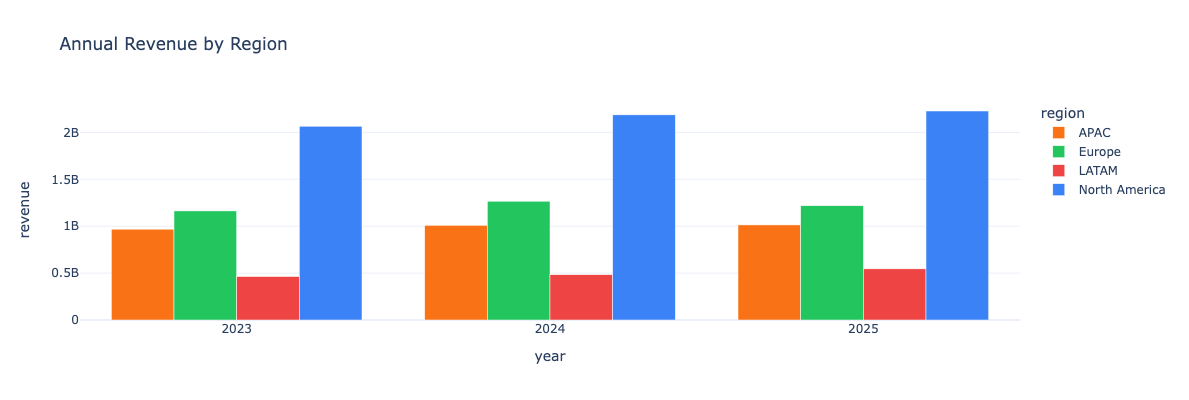


Regional revenue share:
  2023:
    APAC: 20.8%
    Europe: 25.0%
    LATAM: 9.9%
    North America: 44.3%
  2024:
    APAC: 20.4%
    Europe: 25.6%
    LATAM: 9.8%
    North America: 44.2%
  2025:
    APAC: 20.3%
    Europe: 24.3%
    LATAM: 10.9%
    North America: 44.5%


In [17]:
# ── Revenue by region over time ──
region_rev = q("""
    SELECT strftime('%Y', order_date) as year, region,
           SUM(total_amount) as revenue,
           COUNT(*) as orders,
           COUNT(DISTINCT customer_id) as customers
    FROM v_orders_clean
    GROUP BY year, region ORDER BY year, region
""")

fig = px.bar(region_rev, x="year", y="revenue", color="region", barmode="group",
             title="Annual Revenue by Region",
             color_discrete_map={"North America":"#3b82f6", "Europe":"#22c55e",
                                  "APAC":"#f97316", "LATAM":"#ef4444"})
fig.update_layout(height=400, width=800)
fig.show()

# Market share shift
print("\nRegional revenue share:")
for yr in ["2023", "2024", "2025"]:
    yr_data = region_rev[region_rev.year == yr]
    total = yr_data.revenue.sum()
    print(f"  {yr}:")
    for _, r in yr_data.iterrows():
        print(f"    {r.region}: {r.revenue/total*100:.1f}%")


## 10. Summary & Key Findings

### Business Health
- **Revenue:** $14.6B over 3 years. Growth decelerating (6.1% → 1.2%)
- **Customer base:** 8,000 clean customers, 88% active. Healthy retention.
- **AOV:** ~$210K average order. Consistent across years.
- **Returns:** ~5.7% return rate. January spikes expected (post-holiday). No alarming trends.

### Storylines Discovered
1. **Q2 2025 Tariff Shock** — Hardware and consumables revenue dropped significantly. Visible across all regions. Partial recovery in Q3-Q4.
2. **November Spike** — The biggest month every year. B2B fiscal year-end budget flush.
3. **Growth Deceleration** — 2025 grew only 1.2% vs 6.1% the prior year. Tariff impact + market saturation?

### Data Quality Notes
- 240 duplicate customers excluded (3% of base)
- 693 orders excluded (1% — orphaned FKs + future date typos)
- 46K line items excluded (tied to bad orders + price outliers)
- Region variants standardized from 15+ spellings → 4 canonical values

### Questions for Deeper Analysis
- Is the AOV holding up because of mix shift (more software, less hardware) or genuine price resilience?
- Which specific customers churned, and did their order patterns change beforehand?
- Are hardware returns increasing post-tariff (lower quality substitutions)?

In [18]:
conn.close()
print('Notebook complete.')

Notebook complete.
